# Exercise 4

## Import packages

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [14]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    if use_cuda:
        model.to('cuda')
    # TODO: set the model to train mode
    model.train()
    
    
    # TODO: enumerate over the dataloader to get mini batches
    #       of images and ground truth labels
    # HINT: the builtin python function enumerate() also gives you indices
    print(f"Training epoch {epoch}")
    for i, (img, label) in enumerate(train_loader):
    
        # TODO: set the optimizers gradients to zero
        optimizer.zero_grad()
        
        
        # TODO: run the network
        # TODO: compute negative log likelihood loss
        loss = F.nll_loss(model(img), label)
        
        
        # TODO: do backpropagation
        loss.backward()
       
        
        # TODO: optimize
        optimizer.step()
       
        
        # TODO: print current loss for every nth ("log_interval"th) iteration 
        if i % log_interval == 0:
            print(f"   Batch loss at batch {i}: {loss.item()}")
        

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [15]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [16]:
class FCBase(nn.Module):
    def __init__(self):
        super(FCBase, self).__init__()
        self.layers = nn.Sequential(*self.get_layers())

    def forward(self, x):
        x = x.flatten(start_dim=1)
        output = self.layers(x)
        return F.log_softmax(output, dim=1)

    def get_layers(self):
        raise NotImplementedError("Each subclass must implement get_layers()")

In [17]:
class FCNet1(FCBase):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def get_layers(self):
        return [
            nn.Linear(784, 200),
            nn.Sigmoid(),
            nn.Linear(200, 100),
            nn.Sigmoid(),
            nn.Linear(100, 60),
            nn.Sigmoid(),
            nn.Linear(60, 30),
            nn.Sigmoid(),
            nn.Linear(30, 10)
        ]

class FCNet2(FCBase):
    def get_layers(self):
        return [
            nn.Linear(784, 200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 60),
            nn.ReLU(),
            nn.Linear(60, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        ]
    
class FCNet3(FCBase):
    def get_layers(self):
        return [
            nn.Linear(784, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 60),
            nn.BatchNorm1d(60),
            nn.ReLU(),
            nn.Linear(60, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        ]

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [37]:
class BaseConvNet(nn.Module):
    def __init__(self):
        super(BaseConvNet, self).__init__()
        self.conv_layers = nn.Sequential(*self.get_conv_layers())
        self.fc_layers = nn.Sequential(*self.get_fc_layers())

    def forward(self, x):
        # TODO: run convolutional layers
        x_conv = self.conv_layers(x)

        # TODO: reshape batch of images to batch of 1D vectors
        x_reshaped = x_conv.flatten(start_dim=1)
        
        
        # TODO: run fully connected layers
        x_fc = self.fc_layers(x_reshaped)
        
        # TODO: compute log softmax over the output
        output = F.log_softmax(x_fc, dim=1)
        
        return output

    def get_conv_layers(self):
        raise NotImplementedError("Each subclass must implement get_conv_layers()")

    def get_fc_layers(self):
        raise NotImplementedError("Each subclass must implement get_fc_layers()")

In [41]:

class ConvNet1(BaseConvNet):
    """
    Convolutional Neural Network
    
    Two convolutional layers and two fully connected layers
    
    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def get_conv_layers(self):
        return [
                nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0), # 32 Filter (out_channels); 3x3 kernel + stride 1 + padding 0 --> 26x26
                nn.ReLU(),
                nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=0), # 64 Filter (out_channels); 3x3 kernel + stride 2 + padding 0 --> 12x12
                nn.ReLU()
        ]
    def get_fc_layers(self):
        return [
            nn.Linear(64*12*12,128),
            nn.ReLU(),
            nn.Linear(128, 10)
        ]
    
class ConvNet2(BaseConvNet):
    def get_conv_layers(self):
        return [
                nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0), # 32 Filter (out_channels); 3x3 kernel + stride 1 + padding 0 --> 26x26
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=0), # 64 Filter (out_channels); 3x3 kernel + stride 2 + padding 0 --> 12x12
                nn.ReLU()
        ]
    
    def get_fc_layers(self):
        return [
            nn.Linear(64*12*12, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        ]

class ConvNet3(BaseConvNet):
    def get_conv_layers(self):
        return [
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0), # 32 Filter (out_channels); 3x3 kernel + stride 1 + padding 0 --> 26x26
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0), # 64 Filter (out_channels); 3x3 kernel + stride 2 + padding 0 --> 24x24,
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 12x12
        ]
    def get_fc_layers(self):
        return [
            nn.Linear(64*12*12, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        ]

-----------------------------------------------------------------------
Training FCNet1
Training epoch 1
   Batch loss at batch 0: 2.372035026550293
   Batch loss at batch 100: 2.31404709815979
   Batch loss at batch 200: 2.2920022010803223
   Batch loss at batch 300: 2.2943899631500244
   Batch loss at batch 400: 2.289635419845581
   Batch loss at batch 500: 2.293278217315674
   Batch loss at batch 600: 2.3202435970306396
   Batch loss at batch 700: 1.9844903945922852
   Batch loss at batch 800: 1.491304874420166
   Batch loss at batch 900: 1.0806418657302856

Test set: Average loss: 1.1095, Accuracy: 5947/10000 (59.47%)



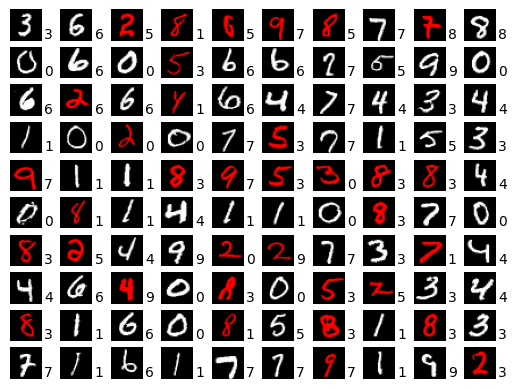

Training epoch 2
   Batch loss at batch 0: 1.1648485660552979
   Batch loss at batch 100: 1.0476758480072021
   Batch loss at batch 200: 0.8817078471183777
   Batch loss at batch 300: 0.7591951489448547
   Batch loss at batch 400: 0.8207595348358154
   Batch loss at batch 500: 0.6653791666030884
   Batch loss at batch 600: 0.569574773311615
   Batch loss at batch 700: 0.429360032081604
   Batch loss at batch 800: 0.4794125258922577
   Batch loss at batch 900: 0.49262017011642456

Test set: Average loss: 0.3985, Accuracy: 9065/10000 (90.65%)



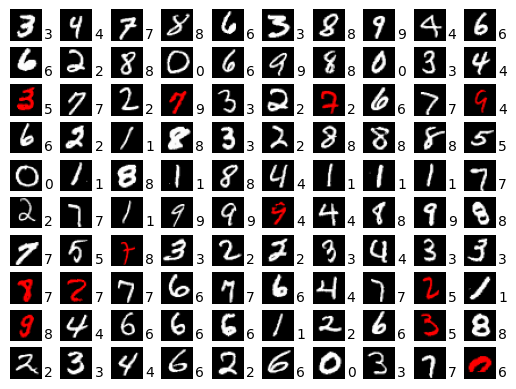

Training epoch 3
   Batch loss at batch 0: 0.31799569725990295
   Batch loss at batch 100: 0.4014829993247986
   Batch loss at batch 200: 0.3598901629447937
   Batch loss at batch 300: 0.26965296268463135
   Batch loss at batch 400: 0.39183536171913147
   Batch loss at batch 500: 0.40627920627593994
   Batch loss at batch 600: 0.12481064349412918
   Batch loss at batch 700: 0.24695004522800446
   Batch loss at batch 800: 0.2963857054710388
   Batch loss at batch 900: 0.2467319518327713

Test set: Average loss: 0.2867, Accuracy: 9278/10000 (92.78%)



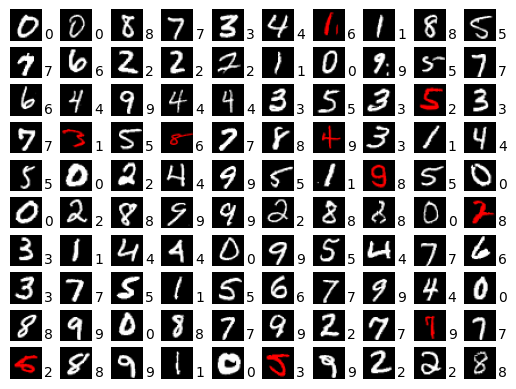

Training epoch 4
   Batch loss at batch 0: 0.32179147005081177
   Batch loss at batch 100: 0.16263170540332794
   Batch loss at batch 200: 0.19697590172290802
   Batch loss at batch 300: 0.3077719807624817
   Batch loss at batch 400: 0.0825062245130539
   Batch loss at batch 500: 0.3891800343990326
   Batch loss at batch 600: 0.1909967064857483
   Batch loss at batch 700: 0.14706073701381683
   Batch loss at batch 800: 0.5151797533035278
   Batch loss at batch 900: 0.40695613622665405

Test set: Average loss: 0.2640, Accuracy: 9320/10000 (93.20%)



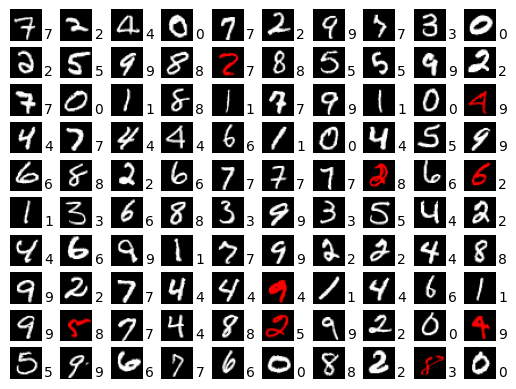

Training epoch 5
   Batch loss at batch 0: 0.06488043069839478
   Batch loss at batch 100: 0.19396622478961945
   Batch loss at batch 200: 0.17840790748596191
   Batch loss at batch 300: 0.19721198081970215
   Batch loss at batch 400: 0.1134900376200676
   Batch loss at batch 500: 0.159197598695755
   Batch loss at batch 600: 0.12087958306074142
   Batch loss at batch 700: 0.10456515103578568
   Batch loss at batch 800: 0.1670812964439392
   Batch loss at batch 900: 0.15007150173187256

Test set: Average loss: 0.2292, Accuracy: 9436/10000 (94.36%)



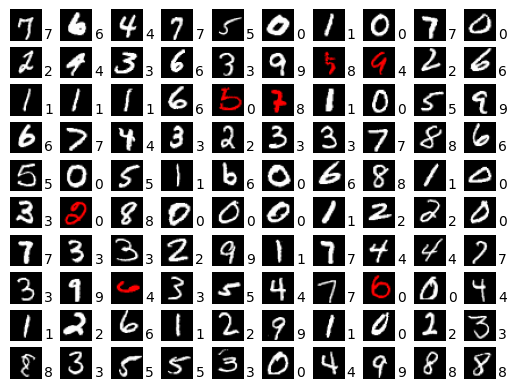

Training epoch 6
   Batch loss at batch 0: 0.30154314637184143
   Batch loss at batch 100: 0.10261067748069763
   Batch loss at batch 200: 0.23374392092227936
   Batch loss at batch 300: 0.18402110040187836
   Batch loss at batch 400: 0.25459954142570496
   Batch loss at batch 500: 0.1810861974954605
   Batch loss at batch 600: 0.10642189532518387
   Batch loss at batch 700: 0.09863516688346863
   Batch loss at batch 800: 0.12968972325325012
   Batch loss at batch 900: 0.1907886564731598

Test set: Average loss: 0.2037, Accuracy: 9503/10000 (95.03%)



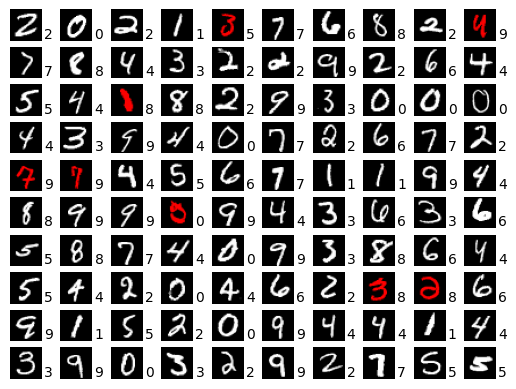

Training epoch 7
   Batch loss at batch 0: 0.19945783913135529
   Batch loss at batch 100: 0.026604365557432175
   Batch loss at batch 200: 0.08762681484222412
   Batch loss at batch 300: 0.21948350965976715
   Batch loss at batch 400: 0.03075149841606617
   Batch loss at batch 500: 0.10178019106388092
   Batch loss at batch 600: 0.19001856446266174
   Batch loss at batch 700: 0.06550733745098114
   Batch loss at batch 800: 0.13396543264389038
   Batch loss at batch 900: 0.0728984996676445

Test set: Average loss: 0.1998, Accuracy: 9524/10000 (95.24%)



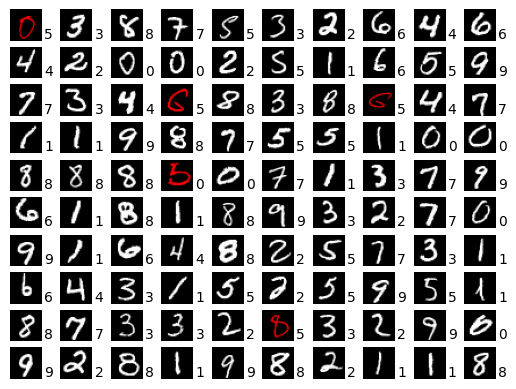

Training epoch 8
   Batch loss at batch 0: 0.04459301382303238
   Batch loss at batch 100: 0.07713695615530014
   Batch loss at batch 200: 0.06128096207976341
   Batch loss at batch 300: 0.22984932363033295
   Batch loss at batch 400: 0.1546904444694519
   Batch loss at batch 500: 0.14362670481204987
   Batch loss at batch 600: 0.21144999563694
   Batch loss at batch 700: 0.060464031994342804
   Batch loss at batch 800: 0.047968652099370956
   Batch loss at batch 900: 0.08619162440299988

Test set: Average loss: 0.1962, Accuracy: 9523/10000 (95.23%)



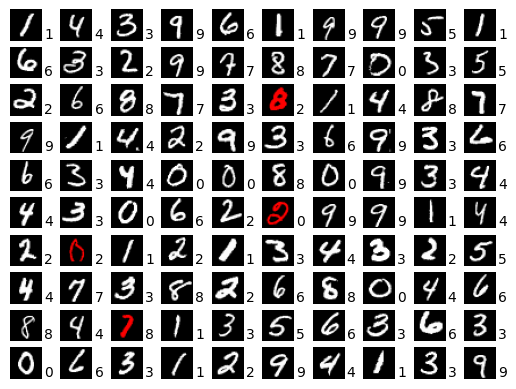

Training epoch 9
   Batch loss at batch 0: 0.042789340019226074
   Batch loss at batch 100: 0.043176062405109406
   Batch loss at batch 200: 0.10252874344587326
   Batch loss at batch 300: 0.14706942439079285
   Batch loss at batch 400: 0.21458832919597626
   Batch loss at batch 500: 0.08930778503417969
   Batch loss at batch 600: 0.03336894512176514
   Batch loss at batch 700: 0.2271898239850998
   Batch loss at batch 800: 0.18458785116672516
   Batch loss at batch 900: 0.14351554214954376

Test set: Average loss: 0.1939, Accuracy: 9533/10000 (95.33%)



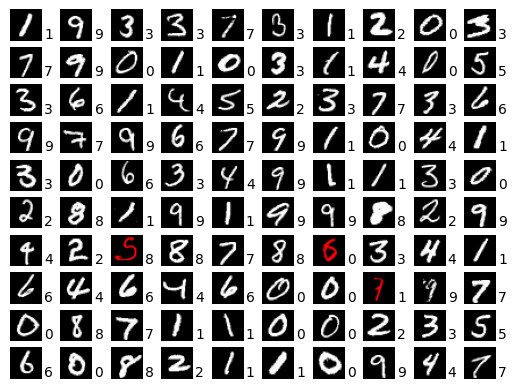

Training epoch 10
   Batch loss at batch 0: 0.14141729474067688
   Batch loss at batch 100: 0.0662025734782219
   Batch loss at batch 200: 0.06821981817483902
   Batch loss at batch 300: 0.23901894688606262
   Batch loss at batch 400: 0.22281567752361298
   Batch loss at batch 500: 0.1461406946182251
   Batch loss at batch 600: 0.04419254884123802
   Batch loss at batch 700: 0.05473581328988075
   Batch loss at batch 800: 0.08510710299015045
   Batch loss at batch 900: 0.04904301092028618

Test set: Average loss: 0.1903, Accuracy: 9543/10000 (95.43%)



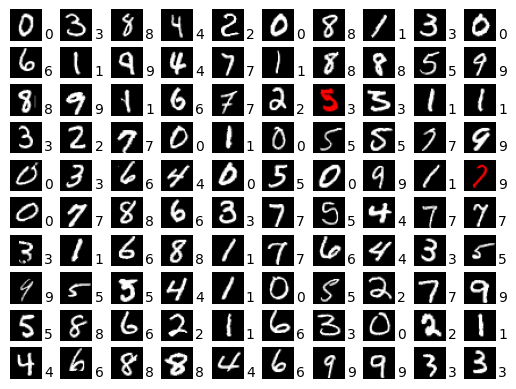

-----------------------------------------------------------------------
Training FCNet2
Training epoch 1
   Batch loss at batch 0: 2.317744493484497
   Batch loss at batch 100: 0.5363546013832092
   Batch loss at batch 200: 0.3664218783378601
   Batch loss at batch 300: 0.3769526481628418
   Batch loss at batch 400: 0.168046772480011
   Batch loss at batch 500: 0.387900710105896
   Batch loss at batch 600: 0.18652324378490448
   Batch loss at batch 700: 0.18922623991966248
   Batch loss at batch 800: 0.10968299210071564
   Batch loss at batch 900: 0.17534571886062622

Test set: Average loss: 0.1223, Accuracy: 9643/10000 (96.43%)



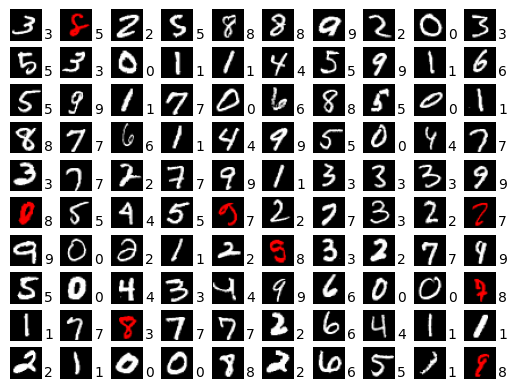

Training epoch 2
   Batch loss at batch 0: 0.026710104197263718
   Batch loss at batch 100: 0.07878336310386658
   Batch loss at batch 200: 0.37922319769859314
   Batch loss at batch 300: 0.10601400583982468
   Batch loss at batch 400: 0.006405399646610022
   Batch loss at batch 500: 0.046355150640010834
   Batch loss at batch 600: 0.1263648122549057
   Batch loss at batch 700: 0.03874834254384041
   Batch loss at batch 800: 0.0704033151268959
   Batch loss at batch 900: 0.06439808756113052

Test set: Average loss: 0.0889, Accuracy: 9743/10000 (97.43%)



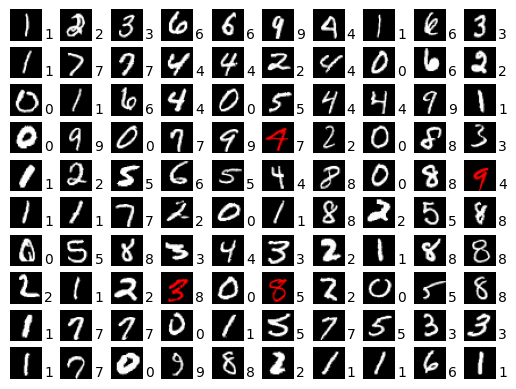

Training epoch 3
   Batch loss at batch 0: 0.2604829967021942
   Batch loss at batch 100: 0.031228279694914818
   Batch loss at batch 200: 0.00358236744068563
   Batch loss at batch 300: 0.001632958767004311
   Batch loss at batch 400: 0.013457342982292175
   Batch loss at batch 500: 0.004252688959240913
   Batch loss at batch 600: 0.048276327550411224
   Batch loss at batch 700: 0.003556478302925825
   Batch loss at batch 800: 0.042632196098566055
   Batch loss at batch 900: 0.05897819995880127

Test set: Average loss: 0.0797, Accuracy: 9784/10000 (97.84%)



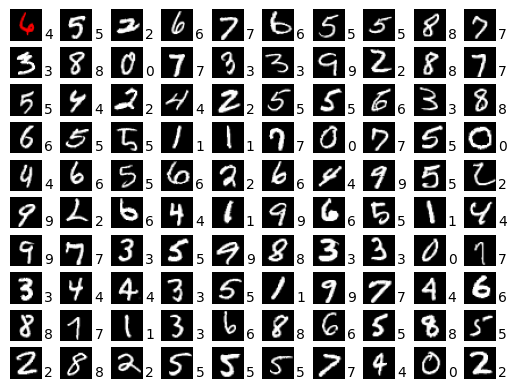

Training epoch 4
   Batch loss at batch 0: 0.039815209805965424
   Batch loss at batch 100: 0.00857706367969513
   Batch loss at batch 200: 0.03854247182607651
   Batch loss at batch 300: 0.015216060914099216
   Batch loss at batch 400: 0.1808329075574875
   Batch loss at batch 500: 0.0028581679798662663
   Batch loss at batch 600: 0.006468599662184715
   Batch loss at batch 700: 0.010651049204170704
   Batch loss at batch 800: 0.18183782696723938
   Batch loss at batch 900: 0.015476119704544544

Test set: Average loss: 0.0772, Accuracy: 9809/10000 (98.09%)



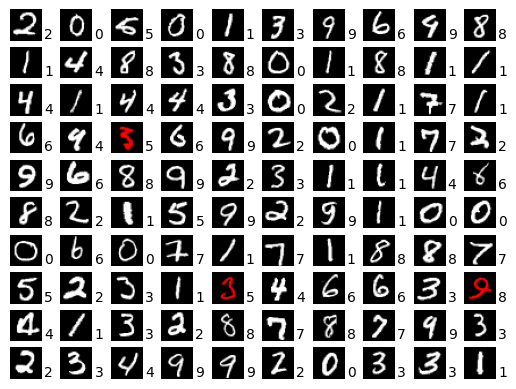

Training epoch 5
   Batch loss at batch 0: 0.003301309421658516
   Batch loss at batch 100: 0.004060572478920221
   Batch loss at batch 200: 0.08960172533988953
   Batch loss at batch 300: 0.001366093405522406
   Batch loss at batch 400: 0.00169688044115901
   Batch loss at batch 500: 0.095616914331913
   Batch loss at batch 600: 0.0029614323284476995
   Batch loss at batch 700: 0.003089854959398508
   Batch loss at batch 800: 0.041136372834444046
   Batch loss at batch 900: 0.004117200151085854

Test set: Average loss: 0.0791, Accuracy: 9801/10000 (98.01%)



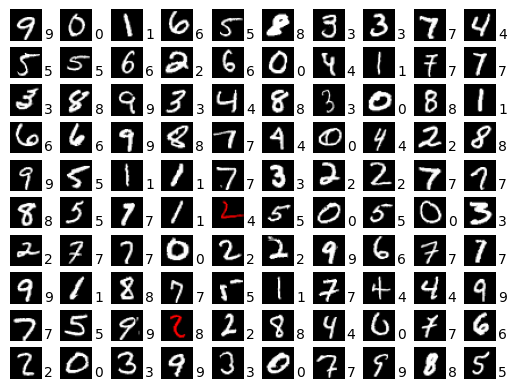

Training epoch 6
   Batch loss at batch 0: 0.057244181632995605
   Batch loss at batch 100: 0.0001716857950668782
   Batch loss at batch 200: 0.0013597924262285233
   Batch loss at batch 300: 0.09072576463222504
   Batch loss at batch 400: 0.0028001798782497644
   Batch loss at batch 500: 0.06510145962238312
   Batch loss at batch 600: 0.005394780542701483
   Batch loss at batch 700: 0.00040089478716254234
   Batch loss at batch 800: 0.004487956408411264
   Batch loss at batch 900: 0.017745250836014748

Test set: Average loss: 0.0859, Accuracy: 9818/10000 (98.18%)



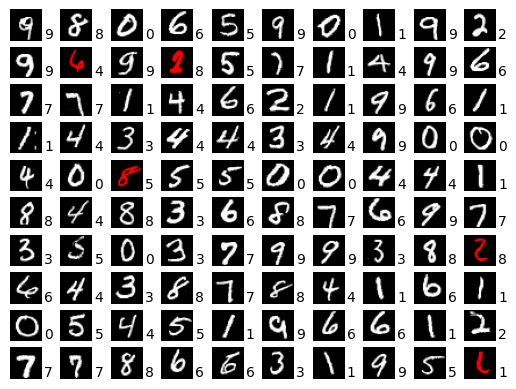

Training epoch 7
   Batch loss at batch 0: 0.0006981320329941809
   Batch loss at batch 100: 0.013204311020672321
   Batch loss at batch 200: 0.00013927614782005548
   Batch loss at batch 300: 0.009719178080558777
   Batch loss at batch 400: 0.0006832015351392329
   Batch loss at batch 500: 0.00992038194090128
   Batch loss at batch 600: 0.0018235064344480634
   Batch loss at batch 700: 0.0034904982894659042
   Batch loss at batch 800: 0.16851288080215454
   Batch loss at batch 900: 0.0003317314258310944

Test set: Average loss: 0.0895, Accuracy: 9799/10000 (97.99%)



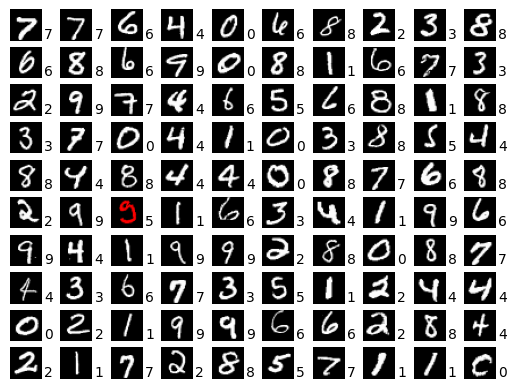

Training epoch 8
   Batch loss at batch 0: 0.000254277401836589
   Batch loss at batch 100: 0.001010674168355763
   Batch loss at batch 200: 0.0008476071525365114
   Batch loss at batch 300: 0.0003309810417704284
   Batch loss at batch 400: 0.004293536767363548
   Batch loss at batch 500: 0.001829746994189918
   Batch loss at batch 600: 0.06704811006784439
   Batch loss at batch 700: 0.0007706635515205562
   Batch loss at batch 800: 0.004490089602768421
   Batch loss at batch 900: 4.304624235373922e-05

Test set: Average loss: 0.0924, Accuracy: 9808/10000 (98.08%)



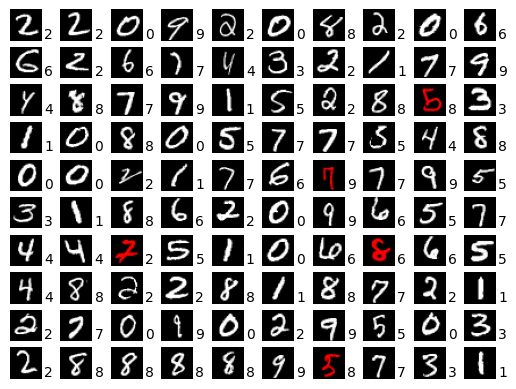

Training epoch 9
   Batch loss at batch 0: 0.0006431607180275023
   Batch loss at batch 100: 0.0012338889064267278
   Batch loss at batch 200: 0.056667082011699677
   Batch loss at batch 300: 0.0001113262478611432
   Batch loss at batch 400: 0.0017938172677531838
   Batch loss at batch 500: 0.1438433825969696
   Batch loss at batch 600: 0.001193383359350264
   Batch loss at batch 700: 0.04053967818617821
   Batch loss at batch 800: 0.0013083290541544557
   Batch loss at batch 900: 0.0008902064291760325

Test set: Average loss: 0.0929, Accuracy: 9814/10000 (98.14%)



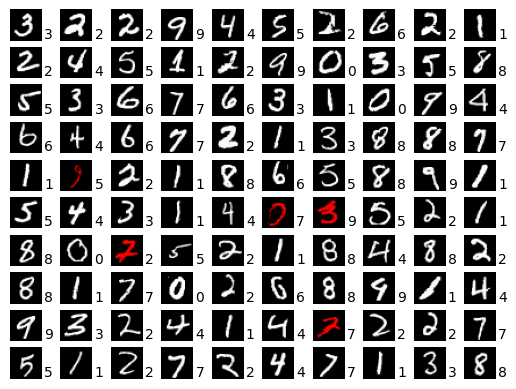

Training epoch 10
   Batch loss at batch 0: 0.0008761878125369549
   Batch loss at batch 100: 0.0013569416478276253
   Batch loss at batch 200: 0.00042222460615448654
   Batch loss at batch 300: 0.021715573966503143
   Batch loss at batch 400: 0.0007202160195447505
   Batch loss at batch 500: 0.04238825663924217
   Batch loss at batch 600: 0.1115223616361618
   Batch loss at batch 700: 0.030361205339431763
   Batch loss at batch 800: 0.0003440527361817658
   Batch loss at batch 900: 0.0031542424112558365

Test set: Average loss: 0.0942, Accuracy: 9812/10000 (98.12%)



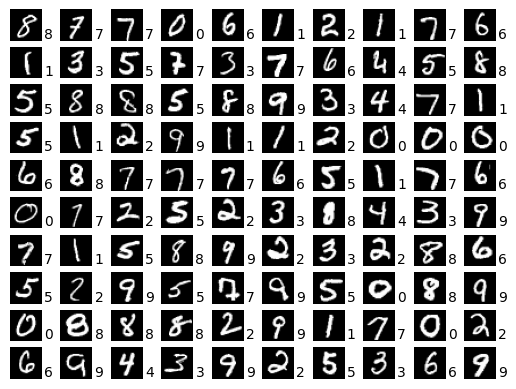

-----------------------------------------------------------------------
Training FCNet3
Training epoch 1
   Batch loss at batch 0: 2.332022190093994
   Batch loss at batch 100: 0.3891112208366394
   Batch loss at batch 200: 0.11060016602277756
   Batch loss at batch 300: 0.19947178661823273
   Batch loss at batch 400: 0.24642160534858704
   Batch loss at batch 500: 0.12815925478935242
   Batch loss at batch 600: 0.197027787566185
   Batch loss at batch 700: 0.08484592288732529
   Batch loss at batch 800: 0.09232601523399353
   Batch loss at batch 900: 0.3383886516094208

Test set: Average loss: 0.1616, Accuracy: 9624/10000 (96.24%)



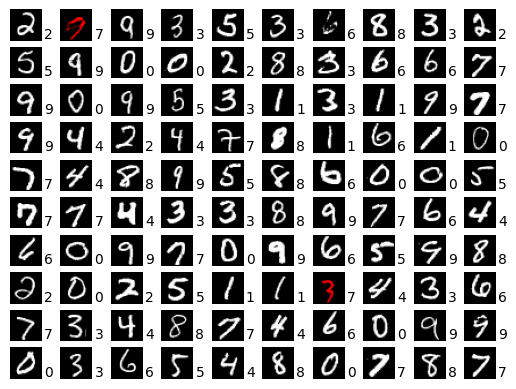

Training epoch 2
   Batch loss at batch 0: 0.08406540006399155
   Batch loss at batch 100: 0.03521665930747986
   Batch loss at batch 200: 0.07323236018419266
   Batch loss at batch 300: 0.029312781989574432
   Batch loss at batch 400: 0.11259022355079651
   Batch loss at batch 500: 0.1167554184794426
   Batch loss at batch 600: 0.20432494580745697
   Batch loss at batch 700: 0.10215144604444504
   Batch loss at batch 800: 0.0550101213157177
   Batch loss at batch 900: 0.034105170518159866

Test set: Average loss: 0.1618, Accuracy: 9699/10000 (96.99%)



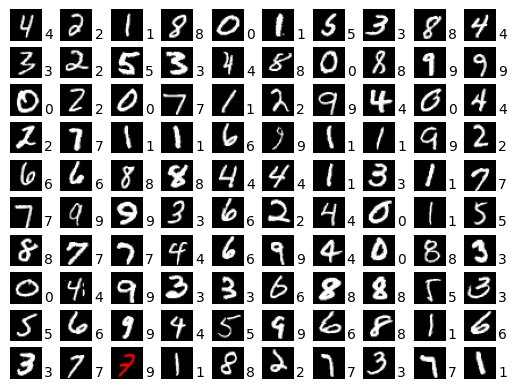

Training epoch 3
   Batch loss at batch 0: 0.04262242838740349
   Batch loss at batch 100: 0.003256118856370449
   Batch loss at batch 200: 0.010644514113664627
   Batch loss at batch 300: 0.041776370257139206
   Batch loss at batch 400: 0.027360685169696808
   Batch loss at batch 500: 0.008880794048309326
   Batch loss at batch 600: 0.024925773963332176
   Batch loss at batch 700: 0.03476889431476593
   Batch loss at batch 800: 0.002758187474682927
   Batch loss at batch 900: 0.01185579039156437

Test set: Average loss: 0.1649, Accuracy: 9728/10000 (97.28%)



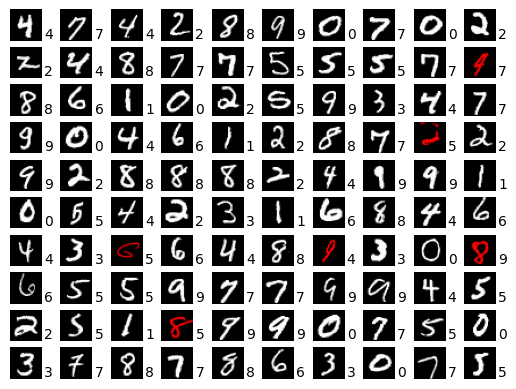

Training epoch 4
   Batch loss at batch 0: 0.011128783226013184
   Batch loss at batch 100: 0.0031821844168007374
   Batch loss at batch 200: 0.02859259396791458
   Batch loss at batch 300: 0.00669621117413044
   Batch loss at batch 400: 0.017678283154964447
   Batch loss at batch 500: 0.011694515123963356
   Batch loss at batch 600: 0.0005186079652048647
   Batch loss at batch 700: 0.005384773947298527
   Batch loss at batch 800: 0.004162462893873453
   Batch loss at batch 900: 0.1167249009013176

Test set: Average loss: 0.1666, Accuracy: 9757/10000 (97.57%)



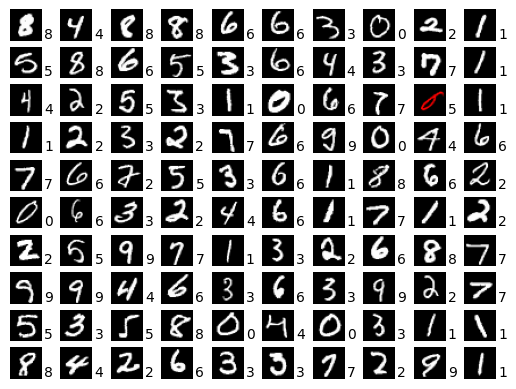

Training epoch 5
   Batch loss at batch 0: 0.0006338800303637981
   Batch loss at batch 100: 0.0064504616893827915
   Batch loss at batch 200: 0.01931579038500786
   Batch loss at batch 300: 0.0063904887065291405
   Batch loss at batch 400: 0.0003829919151030481
   Batch loss at batch 500: 0.005535557866096497
   Batch loss at batch 600: 0.0030176693107932806
   Batch loss at batch 700: 0.01822829060256481
   Batch loss at batch 800: 0.020335638895630836
   Batch loss at batch 900: 0.026376500725746155

Test set: Average loss: 0.1573, Accuracy: 9772/10000 (97.72%)



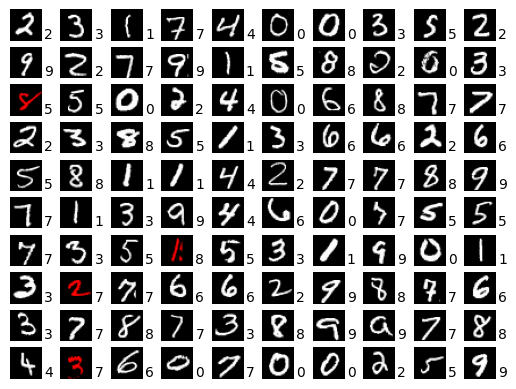

Training epoch 6
   Batch loss at batch 0: 0.0016103227389976382
   Batch loss at batch 100: 0.0058825258165597916
   Batch loss at batch 200: 0.0068264915607869625
   Batch loss at batch 300: 0.009130691178143024
   Batch loss at batch 400: 0.002226657699793577
   Batch loss at batch 500: 0.026130566373467445
   Batch loss at batch 600: 0.025373822078108788
   Batch loss at batch 700: 0.041272327303886414
   Batch loss at batch 800: 0.0071623739786446095
   Batch loss at batch 900: 0.04194176569581032

Test set: Average loss: 0.1411, Accuracy: 9779/10000 (97.79%)



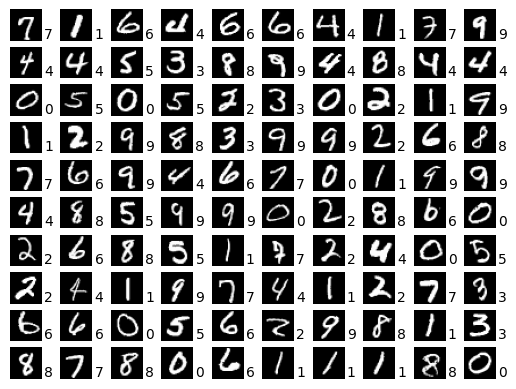

Training epoch 7
   Batch loss at batch 0: 0.036927230656147
   Batch loss at batch 100: 0.0005763970548287034
   Batch loss at batch 200: 0.040038496255874634
   Batch loss at batch 300: 0.003720411565154791
   Batch loss at batch 400: 0.0014564588200300932
   Batch loss at batch 500: 0.003447317983955145
   Batch loss at batch 600: 0.0019580184016376734
   Batch loss at batch 700: 0.04384839907288551
   Batch loss at batch 800: 0.020549479871988297
   Batch loss at batch 900: 0.0041375537402927876

Test set: Average loss: 0.1712, Accuracy: 9774/10000 (97.74%)



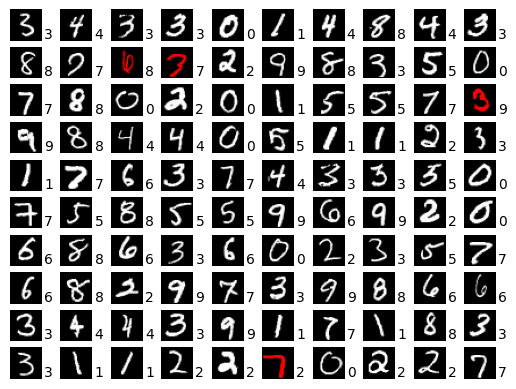

Training epoch 8
   Batch loss at batch 0: 0.00021178333554416895
   Batch loss at batch 100: 0.0016699410043656826
   Batch loss at batch 200: 0.0006353083299472928
   Batch loss at batch 300: 0.005339392926543951
   Batch loss at batch 400: 0.0051009017042815685
   Batch loss at batch 500: 0.0013508421834558249
   Batch loss at batch 600: 0.003391776466742158
   Batch loss at batch 700: 0.0026442944072186947
   Batch loss at batch 800: 0.03586432337760925
   Batch loss at batch 900: 0.0004125330306123942

Test set: Average loss: 0.1646, Accuracy: 9781/10000 (97.81%)



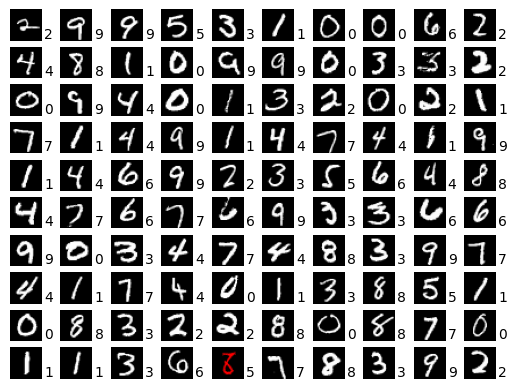

Training epoch 9
   Batch loss at batch 0: 0.00965873897075653
   Batch loss at batch 100: 0.0006625519599765539
   Batch loss at batch 200: 0.0011001540115103126
   Batch loss at batch 300: 0.000655635551083833
   Batch loss at batch 400: 0.0021187642123550177
   Batch loss at batch 500: 0.009988212957978249
   Batch loss at batch 600: 0.07145730406045914
   Batch loss at batch 700: 0.07555580884218216
   Batch loss at batch 800: 0.00593271479010582
   Batch loss at batch 900: 0.009137565270066261

Test set: Average loss: 0.2224, Accuracy: 9774/10000 (97.74%)



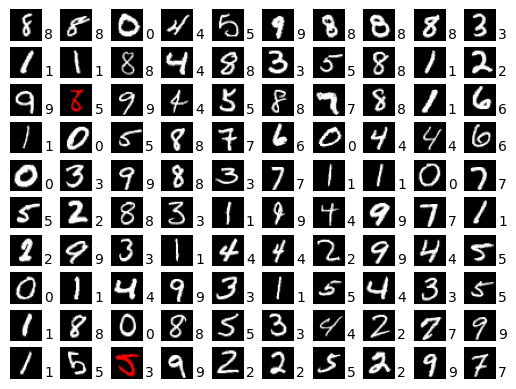

Training epoch 10
   Batch loss at batch 0: 0.006339384242892265
   Batch loss at batch 100: 0.0019344567554071546
   Batch loss at batch 200: 0.00022607504797633737
   Batch loss at batch 300: 0.000487977551529184
   Batch loss at batch 400: 0.07558567076921463
   Batch loss at batch 500: 0.00030905893072485924
   Batch loss at batch 600: 0.0006847995100542903
   Batch loss at batch 700: 0.0019096960313618183
   Batch loss at batch 800: 0.001927945646457374
   Batch loss at batch 900: 0.05323713272809982

Test set: Average loss: 0.1974, Accuracy: 9781/10000 (97.81%)



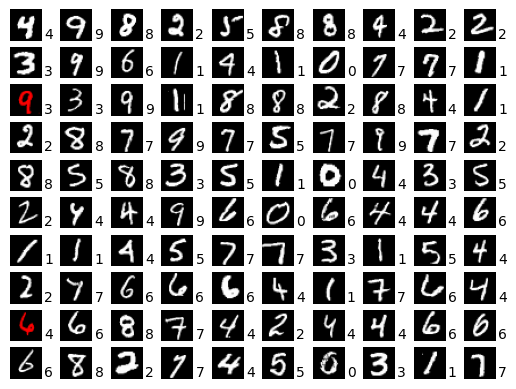

-----------------------------------------------------------------------
Training ConvNet1
Training epoch 1
   Batch loss at batch 0: 2.2986268997192383
   Batch loss at batch 100: 0.17752015590667725
   Batch loss at batch 200: 0.12219270318746567
   Batch loss at batch 300: 0.07402271777391434
   Batch loss at batch 400: 0.10565079748630524
   Batch loss at batch 500: 0.00961265154182911
   Batch loss at batch 600: 0.0991411879658699
   Batch loss at batch 700: 0.02571200393140316
   Batch loss at batch 800: 0.032249122858047485
   Batch loss at batch 900: 0.03447900712490082

Test set: Average loss: 0.0545, Accuracy: 9819/10000 (98.19%)



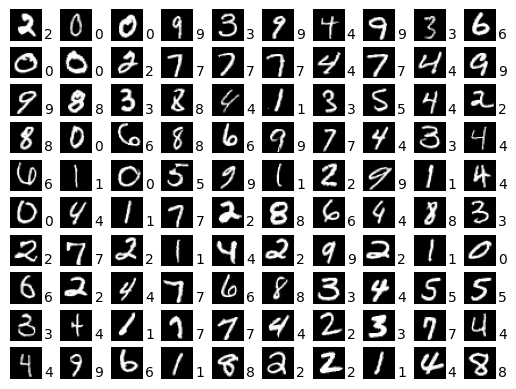

Training epoch 2
   Batch loss at batch 0: 0.06348910927772522
   Batch loss at batch 100: 0.003369009355083108
   Batch loss at batch 200: 0.012019695714116096
   Batch loss at batch 300: 0.054712504148483276
   Batch loss at batch 400: 0.015103482641279697
   Batch loss at batch 500: 0.10963607579469681
   Batch loss at batch 600: 0.07413899898529053
   Batch loss at batch 700: 0.014309542253613472
   Batch loss at batch 800: 0.002133570844307542
   Batch loss at batch 900: 0.04895726591348648

Test set: Average loss: 0.0386, Accuracy: 9878/10000 (98.78%)



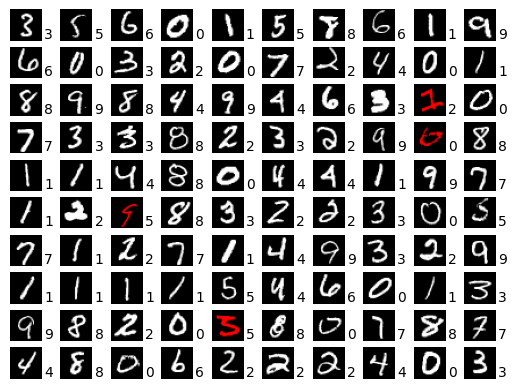

Training epoch 3
   Batch loss at batch 0: 0.0219381432980299
   Batch loss at batch 100: 0.01965303160250187
   Batch loss at batch 200: 0.01722433976829052
   Batch loss at batch 300: 0.001194729469716549
   Batch loss at batch 400: 0.055474210530519485
   Batch loss at batch 500: 0.015740275382995605
   Batch loss at batch 600: 0.013332400470972061
   Batch loss at batch 700: 0.000976914307102561
   Batch loss at batch 800: 0.014481539838016033
   Batch loss at batch 900: 0.023290498182177544

Test set: Average loss: 0.0305, Accuracy: 9903/10000 (99.03%)



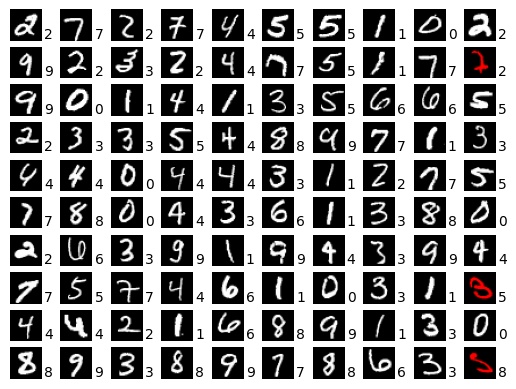

Training epoch 4
   Batch loss at batch 0: 0.0022865398786962032
   Batch loss at batch 100: 0.0024967161007225513
   Batch loss at batch 200: 0.00502140074968338
   Batch loss at batch 300: 0.000558283762075007
   Batch loss at batch 400: 0.0019219863461330533
   Batch loss at batch 500: 0.0010431385599076748
   Batch loss at batch 600: 0.00021076152916066349
   Batch loss at batch 700: 0.0012112825643271208
   Batch loss at batch 800: 0.0020627183839678764
   Batch loss at batch 900: 0.02812531776726246

Test set: Average loss: 0.0323, Accuracy: 9901/10000 (99.01%)



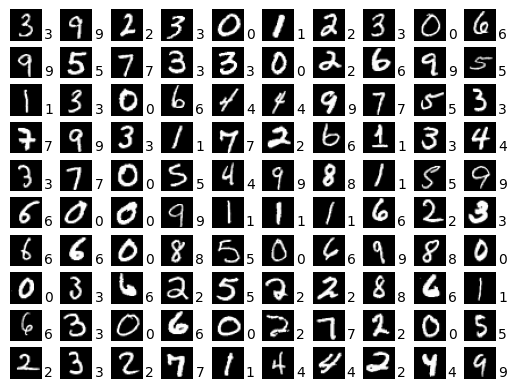

Training epoch 5
   Batch loss at batch 0: 0.0002884047571569681
   Batch loss at batch 100: 0.0003498420992400497
   Batch loss at batch 200: 0.002403360093012452
   Batch loss at batch 300: 0.0003131962730549276
   Batch loss at batch 400: 4.201418414595537e-05
   Batch loss at batch 500: 0.0009244763641618192
   Batch loss at batch 600: 0.0005373041494749486
   Batch loss at batch 700: 0.0018529249355196953
   Batch loss at batch 800: 0.03039158694446087
   Batch loss at batch 900: 0.00041410376434214413

Test set: Average loss: 0.0334, Accuracy: 9899/10000 (98.99%)



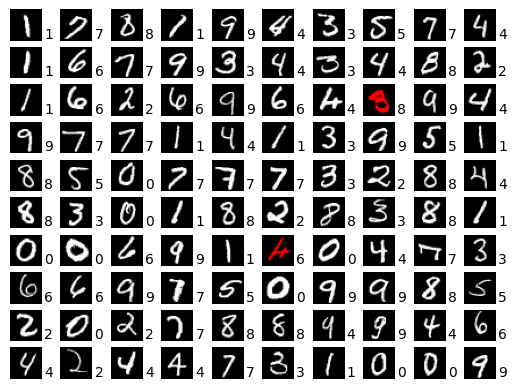

Training epoch 6
   Batch loss at batch 0: 0.00255139940418303
   Batch loss at batch 100: 0.0010150549933314323
   Batch loss at batch 200: 0.00033869058825075626
   Batch loss at batch 300: 0.00018669453857000917
   Batch loss at batch 400: 0.0028735126834362745
   Batch loss at batch 500: 0.0002453236957080662
   Batch loss at batch 600: 0.0021920118015259504
   Batch loss at batch 700: 0.00012457127741072327
   Batch loss at batch 800: 0.00024395775108132511
   Batch loss at batch 900: 2.5610738703107927e-06

Test set: Average loss: 0.0343, Accuracy: 9903/10000 (99.03%)



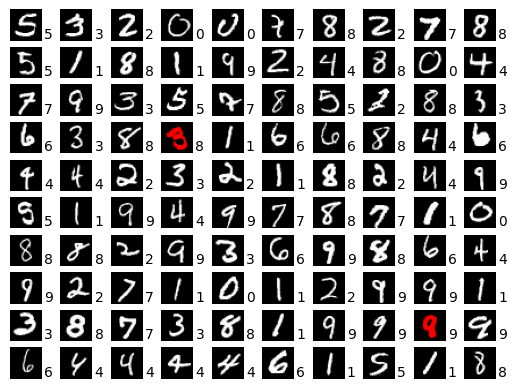

Training epoch 7
   Batch loss at batch 0: 0.0005146273178979754
   Batch loss at batch 100: 0.00021180210751481354
   Batch loss at batch 200: 0.0006190556450746953
   Batch loss at batch 300: 0.00035190340713597834
   Batch loss at batch 400: 0.004264634568244219
   Batch loss at batch 500: 3.4243454138049856e-05
   Batch loss at batch 600: 1.1670372259686701e-05
   Batch loss at batch 700: 0.0011539376573637128
   Batch loss at batch 800: 0.1010785698890686
   Batch loss at batch 900: 0.00010331295197829604

Test set: Average loss: 0.0353, Accuracy: 9901/10000 (99.01%)



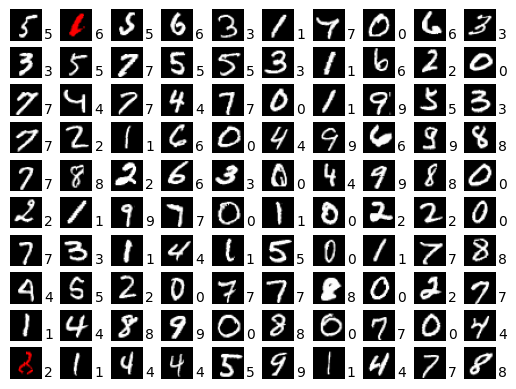

Training epoch 8
   Batch loss at batch 0: 5.7472585467621684e-05
   Batch loss at batch 100: 1.210695700137876e-06
   Batch loss at batch 200: 3.046411984541919e-05
   Batch loss at batch 300: 0.0006617259350605309
   Batch loss at batch 400: 0.0002288934774696827
   Batch loss at batch 500: 0.00013852921256329864
   Batch loss at batch 600: 0.0002493232605047524
   Batch loss at batch 700: 2.0683735783677548e-05
   Batch loss at batch 800: 0.00028844241751357913
   Batch loss at batch 900: 0.0010864731157198548

Test set: Average loss: 0.0361, Accuracy: 9901/10000 (99.01%)



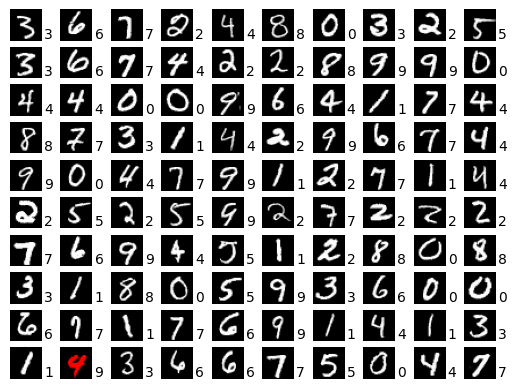

Training epoch 9
   Batch loss at batch 0: 0.00013422554184217006
   Batch loss at batch 100: 0.0005929542821832001
   Batch loss at batch 200: 0.00022291444474831223
   Batch loss at batch 300: 3.5601620766101405e-05
   Batch loss at batch 400: 0.00010387667134637013
   Batch loss at batch 500: 9.205748028762173e-06
   Batch loss at batch 600: 0.00014660238230135292
   Batch loss at batch 700: 7.429236575262621e-05
   Batch loss at batch 800: 0.0002091855276376009
   Batch loss at batch 900: 0.0004381087492220104

Test set: Average loss: 0.0368, Accuracy: 9900/10000 (99.00%)



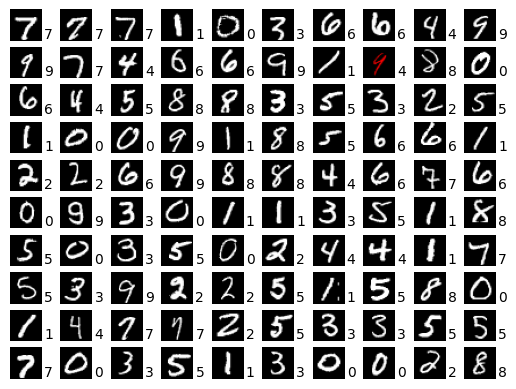

Training epoch 10
   Batch loss at batch 0: 5.1400962547631934e-05
   Batch loss at batch 100: 0.00011455974890850484
   Batch loss at batch 200: 0.00024039250274654478
   Batch loss at batch 300: 0.001818221528083086
   Batch loss at batch 400: 0.0014659515582025051
   Batch loss at batch 500: 0.0007050103740766644
   Batch loss at batch 600: 3.5963992559118196e-05
   Batch loss at batch 700: 0.0009707605931907892
   Batch loss at batch 800: 4.57445094070863e-06
   Batch loss at batch 900: 0.0001970516750589013

Test set: Average loss: 0.0371, Accuracy: 9903/10000 (99.03%)



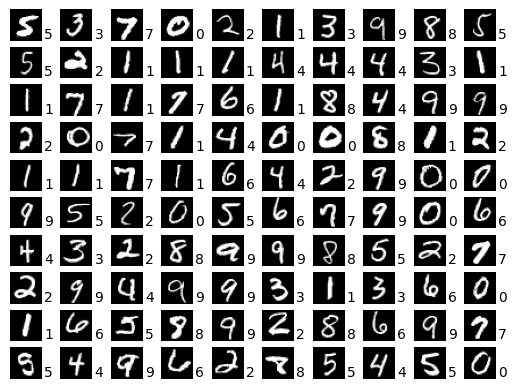

-----------------------------------------------------------------------
Training ConvNet2
Training epoch 1
   Batch loss at batch 0: 2.379262924194336
   Batch loss at batch 100: 0.09951991587877274
   Batch loss at batch 200: 0.141172856092453
   Batch loss at batch 300: 0.01993304118514061
   Batch loss at batch 400: 0.09340766072273254
   Batch loss at batch 500: 0.2356991171836853
   Batch loss at batch 600: 0.04002545773983002
   Batch loss at batch 700: 0.007319341413676739
   Batch loss at batch 800: 0.06111977994441986
   Batch loss at batch 900: 0.014009391888976097

Test set: Average loss: 0.0397, Accuracy: 9870/10000 (98.70%)



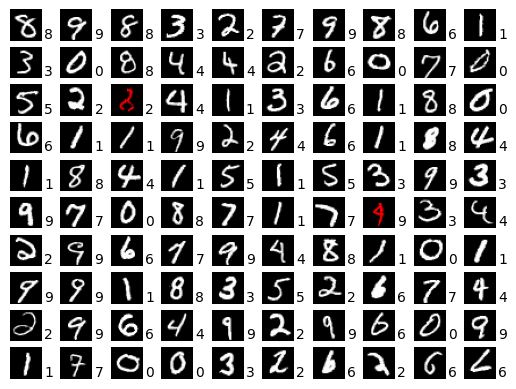

Training epoch 2
   Batch loss at batch 0: 0.018224023282527924
   Batch loss at batch 100: 0.021525569260120392
   Batch loss at batch 200: 0.07856344431638718
   Batch loss at batch 300: 0.010764527134597301
   Batch loss at batch 400: 0.00360498926602304
   Batch loss at batch 500: 0.019106034189462662
   Batch loss at batch 600: 0.14343750476837158
   Batch loss at batch 700: 0.04959443584084511
   Batch loss at batch 800: 0.01756230928003788
   Batch loss at batch 900: 0.006258417386561632

Test set: Average loss: 0.0269, Accuracy: 9915/10000 (99.15%)



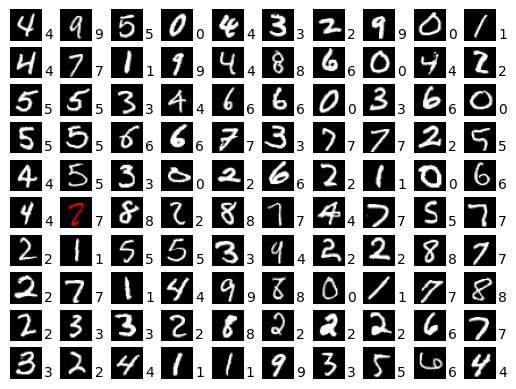

Training epoch 3
   Batch loss at batch 0: 0.004793405532836914
   Batch loss at batch 100: 0.01495757419615984
   Batch loss at batch 200: 0.004028389696031809
   Batch loss at batch 300: 0.004283963702619076
   Batch loss at batch 400: 0.01834804192185402
   Batch loss at batch 500: 0.004331605508923531
   Batch loss at batch 600: 0.0014951849589124322
   Batch loss at batch 700: 0.0013698275433853269
   Batch loss at batch 800: 0.01890287734568119
   Batch loss at batch 900: 0.0027461322024464607

Test set: Average loss: 0.0246, Accuracy: 9913/10000 (99.13%)



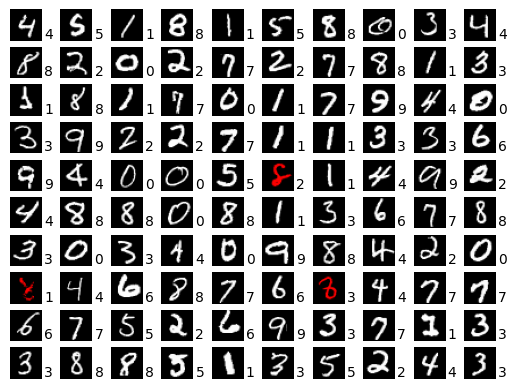

Training epoch 4
   Batch loss at batch 0: 0.001340588554739952
   Batch loss at batch 100: 0.001342328847385943
   Batch loss at batch 200: 0.002410212531685829
   Batch loss at batch 300: 0.02617071568965912
   Batch loss at batch 400: 0.0010675133671611547
   Batch loss at batch 500: 0.0010150843299925327
   Batch loss at batch 600: 0.0010174483759328723
   Batch loss at batch 700: 0.0030086711049079895
   Batch loss at batch 800: 0.0029693127144128084
   Batch loss at batch 900: 0.006601675413548946

Test set: Average loss: 0.0250, Accuracy: 9915/10000 (99.15%)



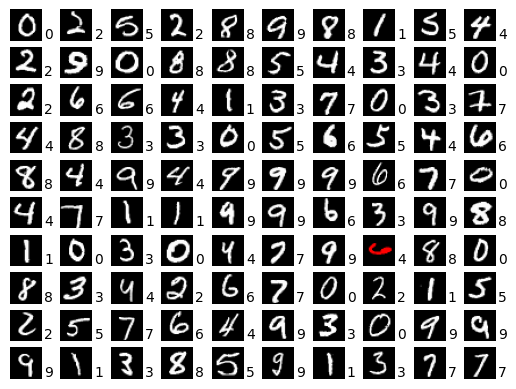

Training epoch 5
   Batch loss at batch 0: 0.010085497982800007
   Batch loss at batch 100: 0.002241936745122075
   Batch loss at batch 200: 0.0002580176224000752
   Batch loss at batch 300: 0.00031731423223391175
   Batch loss at batch 400: 0.0009766004513949156
   Batch loss at batch 500: 0.012959929183125496
   Batch loss at batch 600: 0.0013063799124211073
   Batch loss at batch 700: 0.00022825232008472085
   Batch loss at batch 800: 0.0031406390480697155
   Batch loss at batch 900: 0.0015797738451510668

Test set: Average loss: 0.0247, Accuracy: 9915/10000 (99.15%)



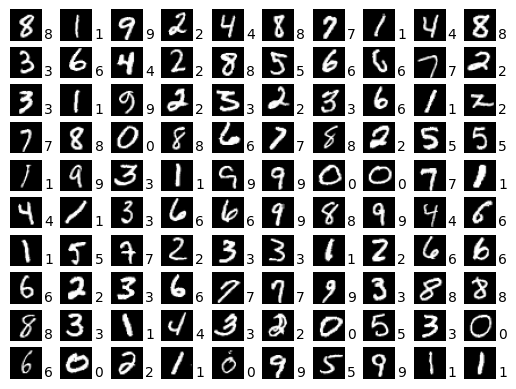

Training epoch 6
   Batch loss at batch 0: 0.0006907896022312343
   Batch loss at batch 100: 0.0015610236441716552
   Batch loss at batch 200: 0.0005287436069920659
   Batch loss at batch 300: 0.0009476080886088312
   Batch loss at batch 400: 0.011499548330903053
   Batch loss at batch 500: 0.00019971445726696402
   Batch loss at batch 600: 0.009758946485817432
   Batch loss at batch 700: 0.0002642728213686496
   Batch loss at batch 800: 0.0036267265677452087
   Batch loss at batch 900: 0.000575231621041894

Test set: Average loss: 0.0258, Accuracy: 9907/10000 (99.07%)



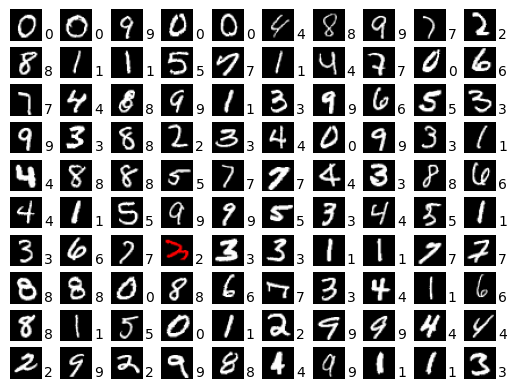

Training epoch 7
   Batch loss at batch 0: 0.0007329043583013117
   Batch loss at batch 100: 0.0032343831844627857
   Batch loss at batch 200: 0.0005452865734696388
   Batch loss at batch 300: 0.005654956214129925
   Batch loss at batch 400: 0.0017643431201577187
   Batch loss at batch 500: 0.0007237611571326852
   Batch loss at batch 600: 0.0018244205275550485
   Batch loss at batch 700: 0.00033700422500260174
   Batch loss at batch 800: 0.0010388982482254505
   Batch loss at batch 900: 0.0011782923247665167

Test set: Average loss: 0.0260, Accuracy: 9908/10000 (99.08%)



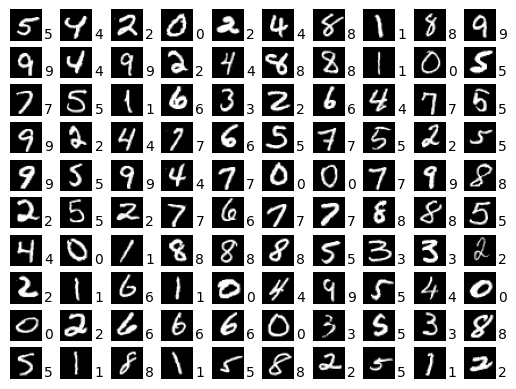

Training epoch 8
   Batch loss at batch 0: 0.0011265636421740055
   Batch loss at batch 100: 0.00021705952531192452
   Batch loss at batch 200: 0.00040433788672089577
   Batch loss at batch 300: 0.0003376338863745332
   Batch loss at batch 400: 0.0005378960631787777
   Batch loss at batch 500: 0.0013026389060541987
   Batch loss at batch 600: 0.0006168612162582576
   Batch loss at batch 700: 0.00047622405691072345
   Batch loss at batch 800: 0.0014802386285737157
   Batch loss at batch 900: 0.004905766807496548

Test set: Average loss: 0.0256, Accuracy: 9917/10000 (99.17%)



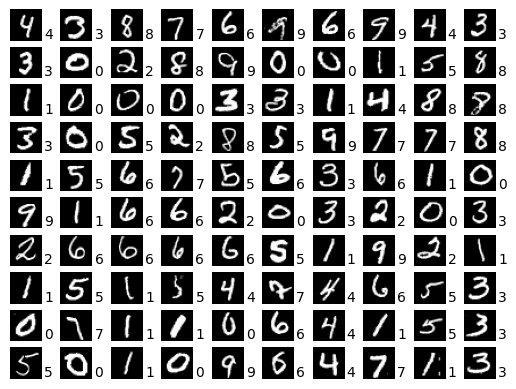

Training epoch 9
   Batch loss at batch 0: 0.00035949412267655134
   Batch loss at batch 100: 0.017729146406054497
   Batch loss at batch 200: 0.0006210943683981895
   Batch loss at batch 300: 0.002736577531322837
   Batch loss at batch 400: 0.0012720221420750022
   Batch loss at batch 500: 0.0003870866494253278
   Batch loss at batch 600: 0.0006790801417082548
   Batch loss at batch 700: 0.0003027462516911328
   Batch loss at batch 800: 0.00027760135708376765
   Batch loss at batch 900: 0.0008382302476093173

Test set: Average loss: 0.0254, Accuracy: 9916/10000 (99.16%)



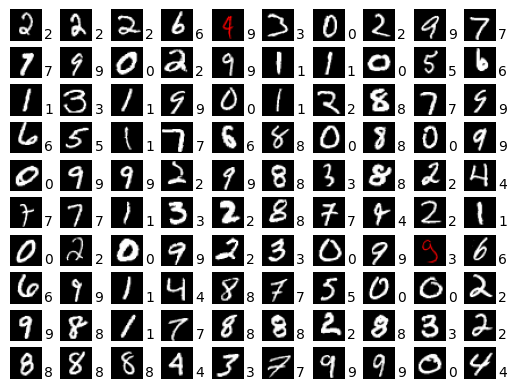

Training epoch 10
   Batch loss at batch 0: 0.0016190876485779881
   Batch loss at batch 100: 0.00043036427814513445
   Batch loss at batch 200: 0.0007112267194315791
   Batch loss at batch 300: 0.002689752960577607
   Batch loss at batch 400: 0.010843289084732533
   Batch loss at batch 500: 0.0003092334954999387
   Batch loss at batch 600: 0.001431113574653864
   Batch loss at batch 700: 0.0028246853034943342
   Batch loss at batch 800: 0.008711826987564564
   Batch loss at batch 900: 0.0005557072581723332

Test set: Average loss: 0.0259, Accuracy: 9916/10000 (99.16%)



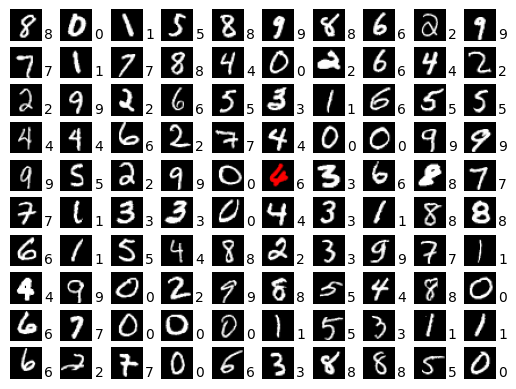

-----------------------------------------------------------------------
Training ConvNet3
Training epoch 1
   Batch loss at batch 0: 2.323676586151123
   Batch loss at batch 100: 0.1963285207748413
   Batch loss at batch 200: 0.08072517067193985
   Batch loss at batch 300: 0.07402007281780243
   Batch loss at batch 400: 0.20791131258010864
   Batch loss at batch 500: 0.09955145418643951
   Batch loss at batch 600: 0.0036017720121890306
   Batch loss at batch 700: 0.010730737820267677
   Batch loss at batch 800: 0.06562722474336624
   Batch loss at batch 900: 0.042465753853321075

Test set: Average loss: 0.0469, Accuracy: 9847/10000 (98.47%)



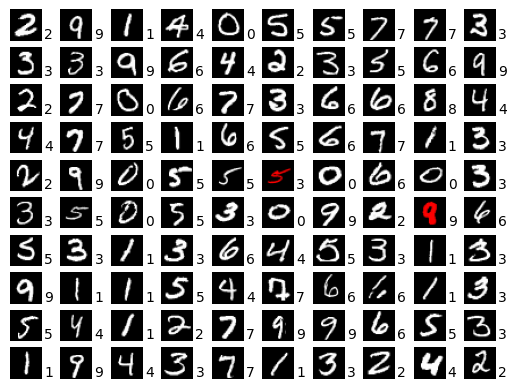

Training epoch 2
   Batch loss at batch 0: 0.013507930561900139
   Batch loss at batch 100: 0.022623609751462936
   Batch loss at batch 200: 0.014043012633919716
   Batch loss at batch 300: 0.0014327852986752987
   Batch loss at batch 400: 0.01593182235956192
   Batch loss at batch 500: 0.050330352038145065
   Batch loss at batch 600: 0.007096253335475922
   Batch loss at batch 700: 0.11922347545623779
   Batch loss at batch 800: 0.005934238899499178
   Batch loss at batch 900: 0.007361486088484526

Test set: Average loss: 0.0329, Accuracy: 9893/10000 (98.93%)



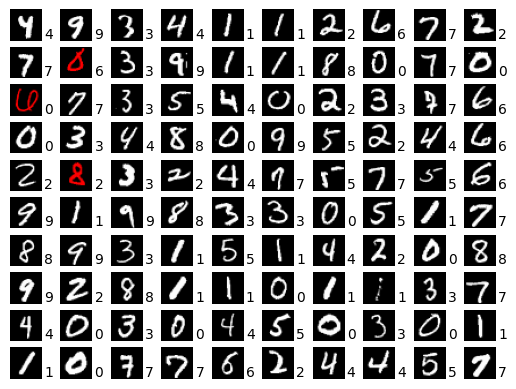

Training epoch 3
   Batch loss at batch 0: 0.0037992731668055058
   Batch loss at batch 100: 0.0012116209836676717
   Batch loss at batch 200: 0.0002792006707750261
   Batch loss at batch 300: 0.001001902506686747
   Batch loss at batch 400: 0.000902434519957751
   Batch loss at batch 500: 0.0005498832324519753
   Batch loss at batch 600: 0.00011720176553353667
   Batch loss at batch 700: 0.00086690962780267
   Batch loss at batch 800: 0.0002936901873908937
   Batch loss at batch 900: 0.008624663576483727

Test set: Average loss: 0.0287, Accuracy: 9910/10000 (99.10%)



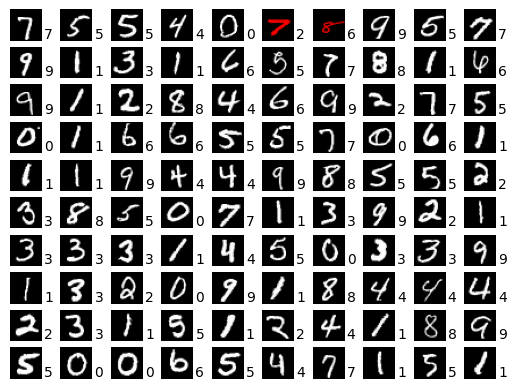

Training epoch 4
   Batch loss at batch 0: 6.142076017567888e-05
   Batch loss at batch 100: 0.00015601834456901997
   Batch loss at batch 200: 0.0005282443598844111
   Batch loss at batch 300: 0.000536459032446146
   Batch loss at batch 400: 0.0015809566248208284
   Batch loss at batch 500: 0.00010738801211118698
   Batch loss at batch 600: 0.0025633261539041996
   Batch loss at batch 700: 0.000866563175804913
   Batch loss at batch 800: 0.003977644722908735
   Batch loss at batch 900: 0.0003935323911719024

Test set: Average loss: 0.0305, Accuracy: 9916/10000 (99.16%)



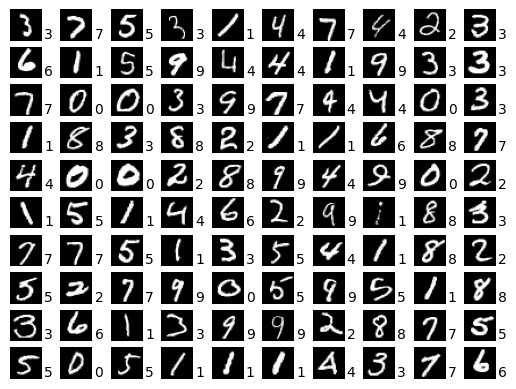

Training epoch 5
   Batch loss at batch 0: 1.118242107622791e-05
   Batch loss at batch 100: 0.00026231096126139164
   Batch loss at batch 200: 1.990452437894419e-05
   Batch loss at batch 300: 0.00011505201837280765
   Batch loss at batch 400: 0.0005454296479001641
   Batch loss at batch 500: 0.00019510708807501942
   Batch loss at batch 600: 4.4770022213924676e-05
   Batch loss at batch 700: 0.00047790491953492165
   Batch loss at batch 800: 0.011853908188641071
   Batch loss at batch 900: 0.0017253622645512223

Test set: Average loss: 0.0335, Accuracy: 9923/10000 (99.23%)



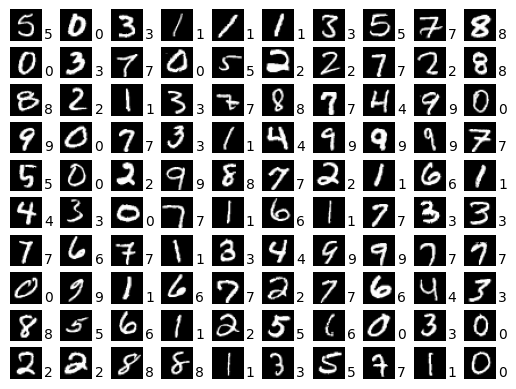

Training epoch 6
   Batch loss at batch 0: 2.2298729163594544e-05
   Batch loss at batch 100: 4.434224319993518e-05
   Batch loss at batch 200: 0.0002615753037389368
   Batch loss at batch 300: 0.00019066210370510817
   Batch loss at batch 400: 3.227942215744406e-05
   Batch loss at batch 500: 0.00015141147014219314
   Batch loss at batch 600: 0.0002023836423177272
   Batch loss at batch 700: 4.828315650229342e-05
   Batch loss at batch 800: 0.0013606948778033257
   Batch loss at batch 900: 1.6085696188383736e-05

Test set: Average loss: 0.0344, Accuracy: 9918/10000 (99.18%)



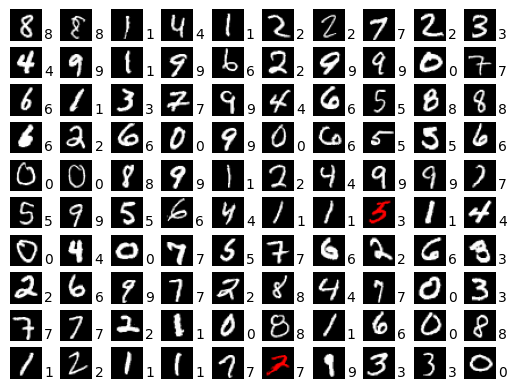

Training epoch 7
   Batch loss at batch 0: 0.002800772897899151
   Batch loss at batch 100: 0.00048463509301654994
   Batch loss at batch 200: 6.209848652360961e-05
   Batch loss at batch 300: 0.0010535299079492688
   Batch loss at batch 400: 0.0006634518504142761
   Batch loss at batch 500: 3.5210287023801357e-05
   Batch loss at batch 600: 6.753291017957963e-06
   Batch loss at batch 700: 0.0004955119220539927
   Batch loss at batch 800: 0.026981083676218987
   Batch loss at batch 900: 3.7326030906115193e-06

Test set: Average loss: 0.0360, Accuracy: 9922/10000 (99.22%)



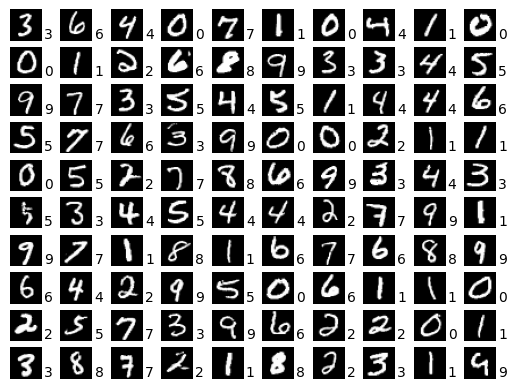

Training epoch 8
   Batch loss at batch 0: 4.3476778955664486e-05
   Batch loss at batch 100: 5.8738671214086935e-05
   Batch loss at batch 200: 0.00046228227438405156
   Batch loss at batch 300: 0.0003944932541344315
   Batch loss at batch 400: 0.00011902196274604648
   Batch loss at batch 500: 0.0006732293404638767
   Batch loss at batch 600: 0.00019088936096522957
   Batch loss at batch 700: 5.4549804190173745e-05
   Batch loss at batch 800: 1.2499771401053295e-05
   Batch loss at batch 900: 0.0003863943857140839

Test set: Average loss: 0.0364, Accuracy: 9917/10000 (99.17%)



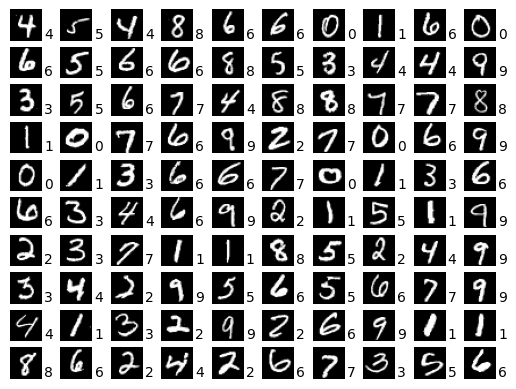

Training epoch 9
   Batch loss at batch 0: 0.00013243367720860988
   Batch loss at batch 100: 9.590838453732431e-05
   Batch loss at batch 200: 6.710542947985232e-06
   Batch loss at batch 300: 1.0809682862600312e-05
   Batch loss at batch 400: 2.836715339071816e-06
   Batch loss at batch 500: 7.13641638867557e-05
   Batch loss at batch 600: 1.3285557542985771e-05
   Batch loss at batch 700: 6.581138586625457e-05
   Batch loss at batch 800: 0.00025147496489807963
   Batch loss at batch 900: 0.001627719379030168

Test set: Average loss: 0.0367, Accuracy: 9917/10000 (99.17%)



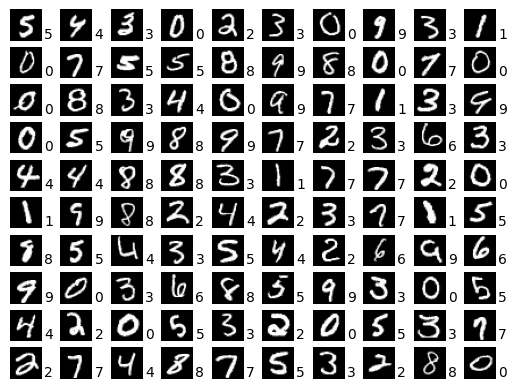

Training epoch 10
   Batch loss at batch 0: 6.273575854720548e-05
   Batch loss at batch 100: 0.00025265649310313165
   Batch loss at batch 200: 0.0001235149393323809
   Batch loss at batch 300: 0.00016573778702877462
   Batch loss at batch 400: 0.0009403976728208363
   Batch loss at batch 500: 2.4150511308107525e-05
   Batch loss at batch 600: 6.343828863464296e-05
   Batch loss at batch 700: 3.0449900805251673e-05
   Batch loss at batch 800: 5.145572868059389e-05
   Batch loss at batch 900: 2.8981199648114853e-05

Test set: Average loss: 0.0369, Accuracy: 9917/10000 (99.17%)



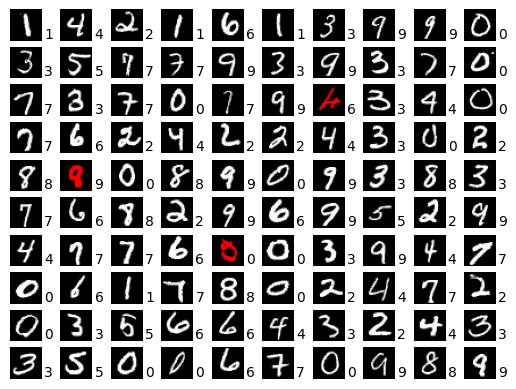

In [45]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

# train all models and save them
models = [
    FCNet1(),
    FCNet2(),
    FCNet3(),
    ConvNet1(),
    ConvNet2(),
    ConvNet3()
]


model_names = ["FCNet1", "FCNet2", "FCNet3", "ConvNet1", "ConvNet2", "ConvNet3"]

for model, model_name in zip(models, model_names):
    print('-----------------------------------------------------------------------')
    print(f"Training {model_name}")
    if use_cuda:
        model = model.cuda()

    # initialize optimizer and scheduler
    optimizer = optim.Adadelta(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

    for epoch in range(1, epochs + 1):
        # train one epoch
        train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
        
        # run on test dataset
        validate(model, use_cuda, test_loader)
        scheduler.step()
        torch.save(model.state_dict(), "models/mnist/checkpoint.pt")
        #torch.save(model.state_dict(), f"models/mnist/{model_name}.pt")